#### 2026.07.06
비지도 학습

#### K-Means

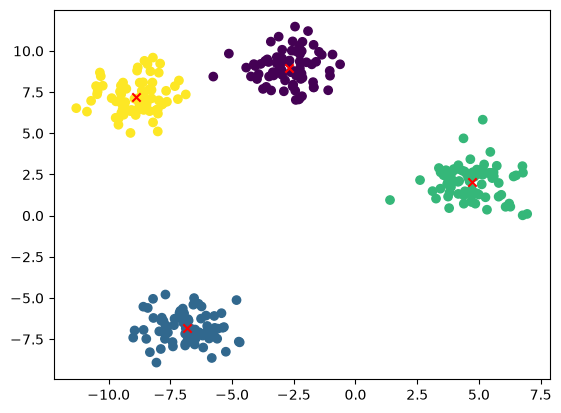

In [11]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=300,
    centers=4,
    random_state=42
)
#plt.scatter(X[:,0],X[:, 1])

kmeans = KMeans(
    n_clusters=4,
    init='k-means++', # 랜덤하게 만들어지는 중심값을 멀리 떨어뜨려서 만드는 옵션
    random_state=42
)

cluster_labels = kmeans.fit_predict(X)

#print(cluster_labels)
#print(kmeans.cluster_centers_)

plt.scatter(X[:,0], X[:,1], c=cluster_labels,cmap='viridis')
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c='r',
    marker='x'
)

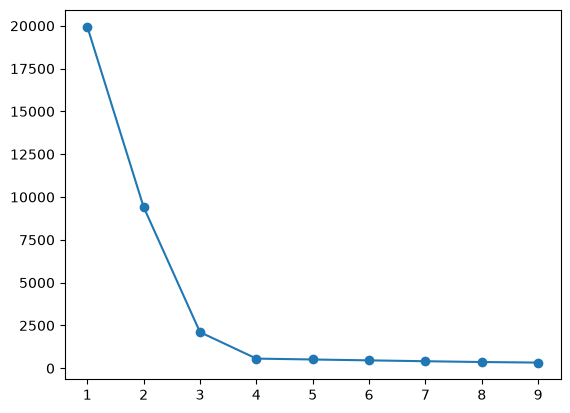

In [ ]:
result = []
for k in range(1,10):
    kmeans_temp = KMeans(n_clusters=k,init='k-means++',random_state=42)
    kmeans_temp.fit_predict(X)
    result.append(kmeans_temp.inertia_) # 거리값

plt.plot(range(1,10),result, marker='o') # k=4

In [16]:
# 실루엣 점수
from sklearn.metrics import silhouette_score, silhouette_samples
sil_score = silhouette_score(X,cluster_labels)
print(sil_score)

sil_values = silhouette_samples(X,cluster_labels)
print(sil_values)

0.7915830011443039
[0.80600451 0.80216071 0.73893458 0.87948243 0.71930267 0.90063471
 0.8710494  0.90827138 0.79909098 0.79917381 0.67810765 0.86416759
 0.66819132 0.67698901 0.81012669 0.77928758 0.75408624 0.72665936
 0.78160132 0.68083316 0.84037847 0.80749222 0.89582869 0.81516562
 0.78945463 0.6456291  0.7639259  0.7951111  0.90158165 0.82779032
 0.73468472 0.8178537  0.73802264 0.84127989 0.68750863 0.75713022
 0.74374922 0.91150739 0.79603318 0.82637541 0.8389285  0.81272915
 0.81488503 0.87235309 0.75172136 0.73802997 0.81210162 0.86328129
 0.80005662 0.81162246 0.90816901 0.68055866 0.8980895  0.74146687
 0.88514061 0.53179664 0.79581203 0.85366183 0.86145934 0.75707197
 0.74493573 0.76455439 0.85817039 0.0634864  0.88575261 0.88640631
 0.9001295  0.88313919 0.8544984  0.73852637 0.87870933 0.84510454
 0.79577041 0.87230205 0.70250671 0.79789834 0.83317117 0.89781966
 0.78855388 0.88348048 0.74987952 0.77679308 0.76667658 0.7801336
 0.8919131  0.72102419 0.67459466 0.80748076

76
75
75
74


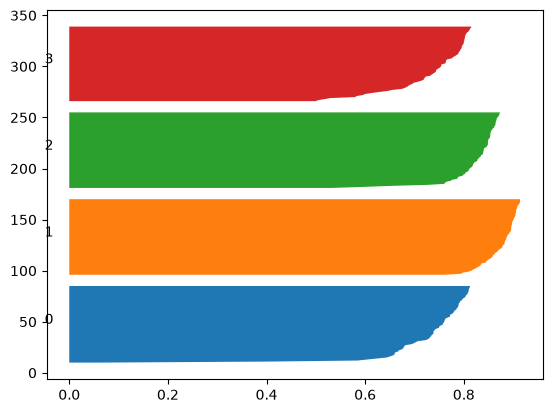

In [ ]:
import numpy as np

# 시각화준비
y_lower = 10
for i in range(4): # 각 클러스터에대해 반복
    ith_cluster_silhouette_values = sil_values[cluster_labels == i]
    #print(ith_cluster_silhouette_values)
    # 정렬
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    #print(size_cluster_i)
    y_upper = y_lower + size_cluster_i
    # 클러스터별막대 그리기
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0,ith_cluster_silhouette_values)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i)) # 클러스터번호
    y_lower = y_upper + 10 # 다음 클러스터로이동


차원축소 : PCA

In [14]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data   # 특성 : 4차원 -> 2차원
y = iris.target # 0, 1, 2
print(X.shape)    

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2) # 2개의 주성분으로 축소
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)


(150, 4)
(150, 2)


In [ ]:
# 주성분이 데이터를 얼마나 잘 설명하는 지 지표 확인
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


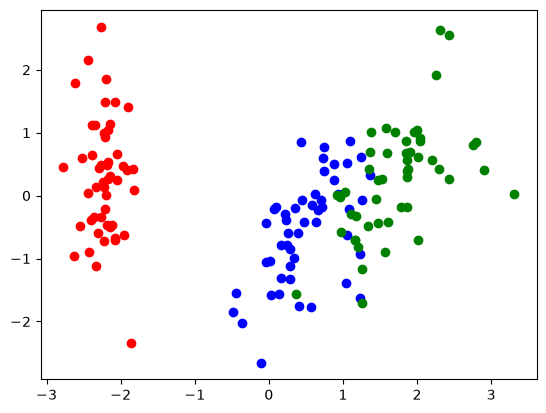

In [15]:
import matplotlib.pyplot as plt

for target,color,label in zip([0,1,2], ['red', 'blue', 'green'], iris.target_names):
    plt.scatter(
        X_pca[y==target, 0], # 첫번째 주성분
        X_pca[y==target, 1], # 두번째 주성분 
        color=color,
        label=label       
    )

Isolation Forest: 이상치 탐지

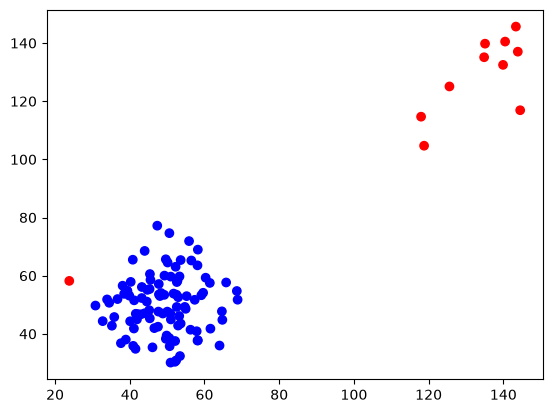

In [10]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest # 트리 모델 앙상블
import matplotlib.pyplot as plt

np.random.seed(42)

# 정상데이터 100개, 2차원
# 평균 50 표준편차 10 
normal_traffic = np.random.normal(loc=50, scale=10, size=(100,2)) 
# print(normal_traffic)

# 이상 데이터 10개, 2차원
ano_traffic = np.random.uniform(low=100, high=150, size=(10,2))
#print(ano_traffic)

# 데이터 병합 vstack()
traffic_data = np.vstack((normal_traffic, ano_traffic))
#print(traffic_data)

traffic_df = pd.DataFrame(traffic_data,columns=['Request Time', 'Response Time'])

# 학습 모델 생성
model = IsolationForest(
    n_estimators=100,       # 트리 갯수
    contamination=0.1,      # 몇 프로
    random_state=42   
)

# -1 이상 / 1 정상
traffic_df['Anomaly Score'] = model.fit_predict(traffic_df)

plt.scatter(
    traffic_df['Request Time'],
    traffic_df['Response Time'],
    c=traffic_df['Anomaly Score'].map({1:'blue', -1:'red'})
)

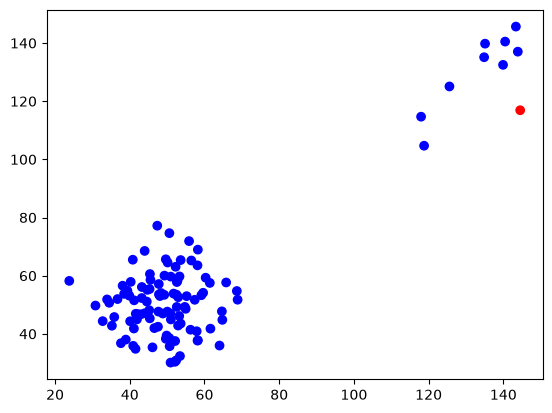

In [11]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=15, min_samples=3)
# 이상치 : -1, 나머지 : 클러스터 ID
traffic_df['Cluster'] = dbscan.fit_predict(traffic_df)

traffic_df['Anomaly'] = traffic_df['Cluster'].apply(lambda x : 'Anomaly' if x==-1 else 'Normal')

plt.scatter(
    traffic_df['Request Time'],
    traffic_df['Response Time'],
    c=traffic_df['Anomaly'].map({'Normal':'blue','Anomaly':'red'})
)